# PERSONAL INFORMATION

Name: ERICK ELEAZAR MEJIA MOSCOSO   

ID: 20006104

# Requirements:

*   Implement the whole ML Pipeline (Acquire data, pre-process data, create model, train model & evaluate model)
*   Accuracy must be above 40%
*   Must use the Tensorboard and display the model's train process
*   Must use the following Callbacks: EarlyStopping and ModelCheckpoint
*   Extra (+10): Include confusion Matrix and 2 suggestions on how to improve the model (just write them, do not implement them)




## Preparations

In [ ]:
# ----- Libraries ----- #

# This is the main Library that allows us to work with Neural Networks
import tensorflow as tf


# For graph plotting
import matplotlib.pyplot as plt
from tensorflow.math import confusion_matrix

# For dataset manipulation
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# For visualizing more complex graphs
import seaborn as sns

# Global constant for training acceleration
AUTOTUNE = tf.data.AUTOTUNE

# 1) Dataset Preparations

In [ ]:
'''
The dataset you are going to use is the following:
https://archive.ics.uci.edu/ml/datasets/Credit+Approval
'''

# Getting Dataset
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/cpu-performance/machine.data

--2025-03-16 04:02:31--  https://archive.ics.uci.edu/ml/machine-learning-databases/cpu-performance/machine.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘machine.data.1’

machine.data.1          [ <=>                ]   8.52K  --.-KB/s    in 0s      

2025-03-16 04:02:31 (104 MB/s) - ‘machine.data.1’ saved [8726]



In [ ]:
# Loading Dataset and have a glimpse about it
column_names = ['VendorName','ModelName','MYCT','MMIN','MMAX',
                'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']

raw_dataset = pd.read_csv("machine.data", names=column_names,
                      na_values = "?", comment='\t',
                      sep=",", skipinitialspace=True)

In [ ]:
# Brief Statistical Summary of the dataset
raw_dataset.describe()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
count,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000
mean,203.822967,2867.980861,11796.153110,25.205742,4.698565,18.267943,105.622010,99.330144
std,260.262926,3878.742758,11726.564377,40.628722,6.816274,25.997318,160.830733,154.757102
min,17.000000,64.000000,64.000000,0.000000,0.000000,0.000000,6.000000,15.000000
25%,50.000000,768.000000,4000.000000,0.000000,1.000000,5.000000,27.000000,28.000000
50%,110.000000,2000.000000,8000.000000,8.000000,2.000000,8.000000,50.000000,45.000000
75%,225.000000,4000.000000,16000.000000,32.000000,6.000000,24.000000,113.000000,101.000000
max,1500.000000,32000.000000,64000.000000,256.000000,52.000000,176.000000,1150.000000,1238.000000


In [ ]:
# Shape is a fancy way of calling Dataset's dimension
raw_dataset.shape

(209, 10)

In [ ]:
# Check all the unique values
raw_dataset["VendorName"].unique()

array(['adviser', 'amdahl', 'apollo', 'basf', 'bti', 'burroughs', 'c.r.d',
       'cdc', 'cambex', 'dec', 'dg', 'formation', 'four-phase', 'gould',
       'hp', 'harris', 'honeywell', 'ibm', 'ipl', 'magnuson', 'microdata',
       'nas', 'ncr', 'nixdorf', 'perkin-elmer', 'prime', 'siemens',
       'sperry', 'sratus', 'wang'], dtype=object)

In [ ]:
# Check all the unique values
raw_dataset["ModelName"].unique()

array(['32/60', '470v/7', '470v/7a', '470v/7b', '470v/7c', '470v/b',
       '580-5840', '580-5850', '580-5860', '580-5880', 'dn320', 'dn420',
       '7/65', '7/68', '5000', '8000', 'b1955', 'b2900', 'b2925', 'b4955',
       'b5900', 'b5920', 'b6900', 'b6925', '68/10-80', 'universe:2203t',
       'universe:68', 'universe:68/05', 'universe:68/137',
       'universe:68/37', 'cyber:170/750', 'cyber:170/760',
       'cyber:170/815', 'cyber:170/825', 'cyber:170/835', 'cyber:170/845',
       'omega:480-i', 'omega:480-ii', 'omega:480-iii', '1636-1',
       '1636-10', '1641-1', '1641-11', '1651-1', 'decsys:10:1091',
       'decsys:20:2060', 'microvax-1', 'vax:11/730', 'vax:11/750',
       'vax:11/780', 'eclipse:c/350', 'eclipse:m/600', 'eclipse:mv/10000',
       'eclipse:mv/4000', 'eclipse:mv/6000', 'eclipse:mv/8000',
       'eclipse:mv/8000-ii', 'f4000/100', 'f4000/200', 'f4000/200ap',
       'f4000/300', 'f4000/300ap', '2000/260', 'concept:32/8705',
       'concept:32/8750', 'concept:32/8780'

In [ ]:
# Lets make a copy
new_dataset = raw_dataset.copy()

# Lets check for null values
print(new_dataset.isna().sum())

# Dropping null rows
new_dataset = new_dataset.dropna()

# Checking new dataset
new_dataset.head()

VendorName    0
ModelName     0
MYCT          0
MMIN          0
MMAX          0
CACH          0
CHMIN         0
CHMAX         0
PRP           0
ERP           0
dtype: int64


,VendorName,ModelName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


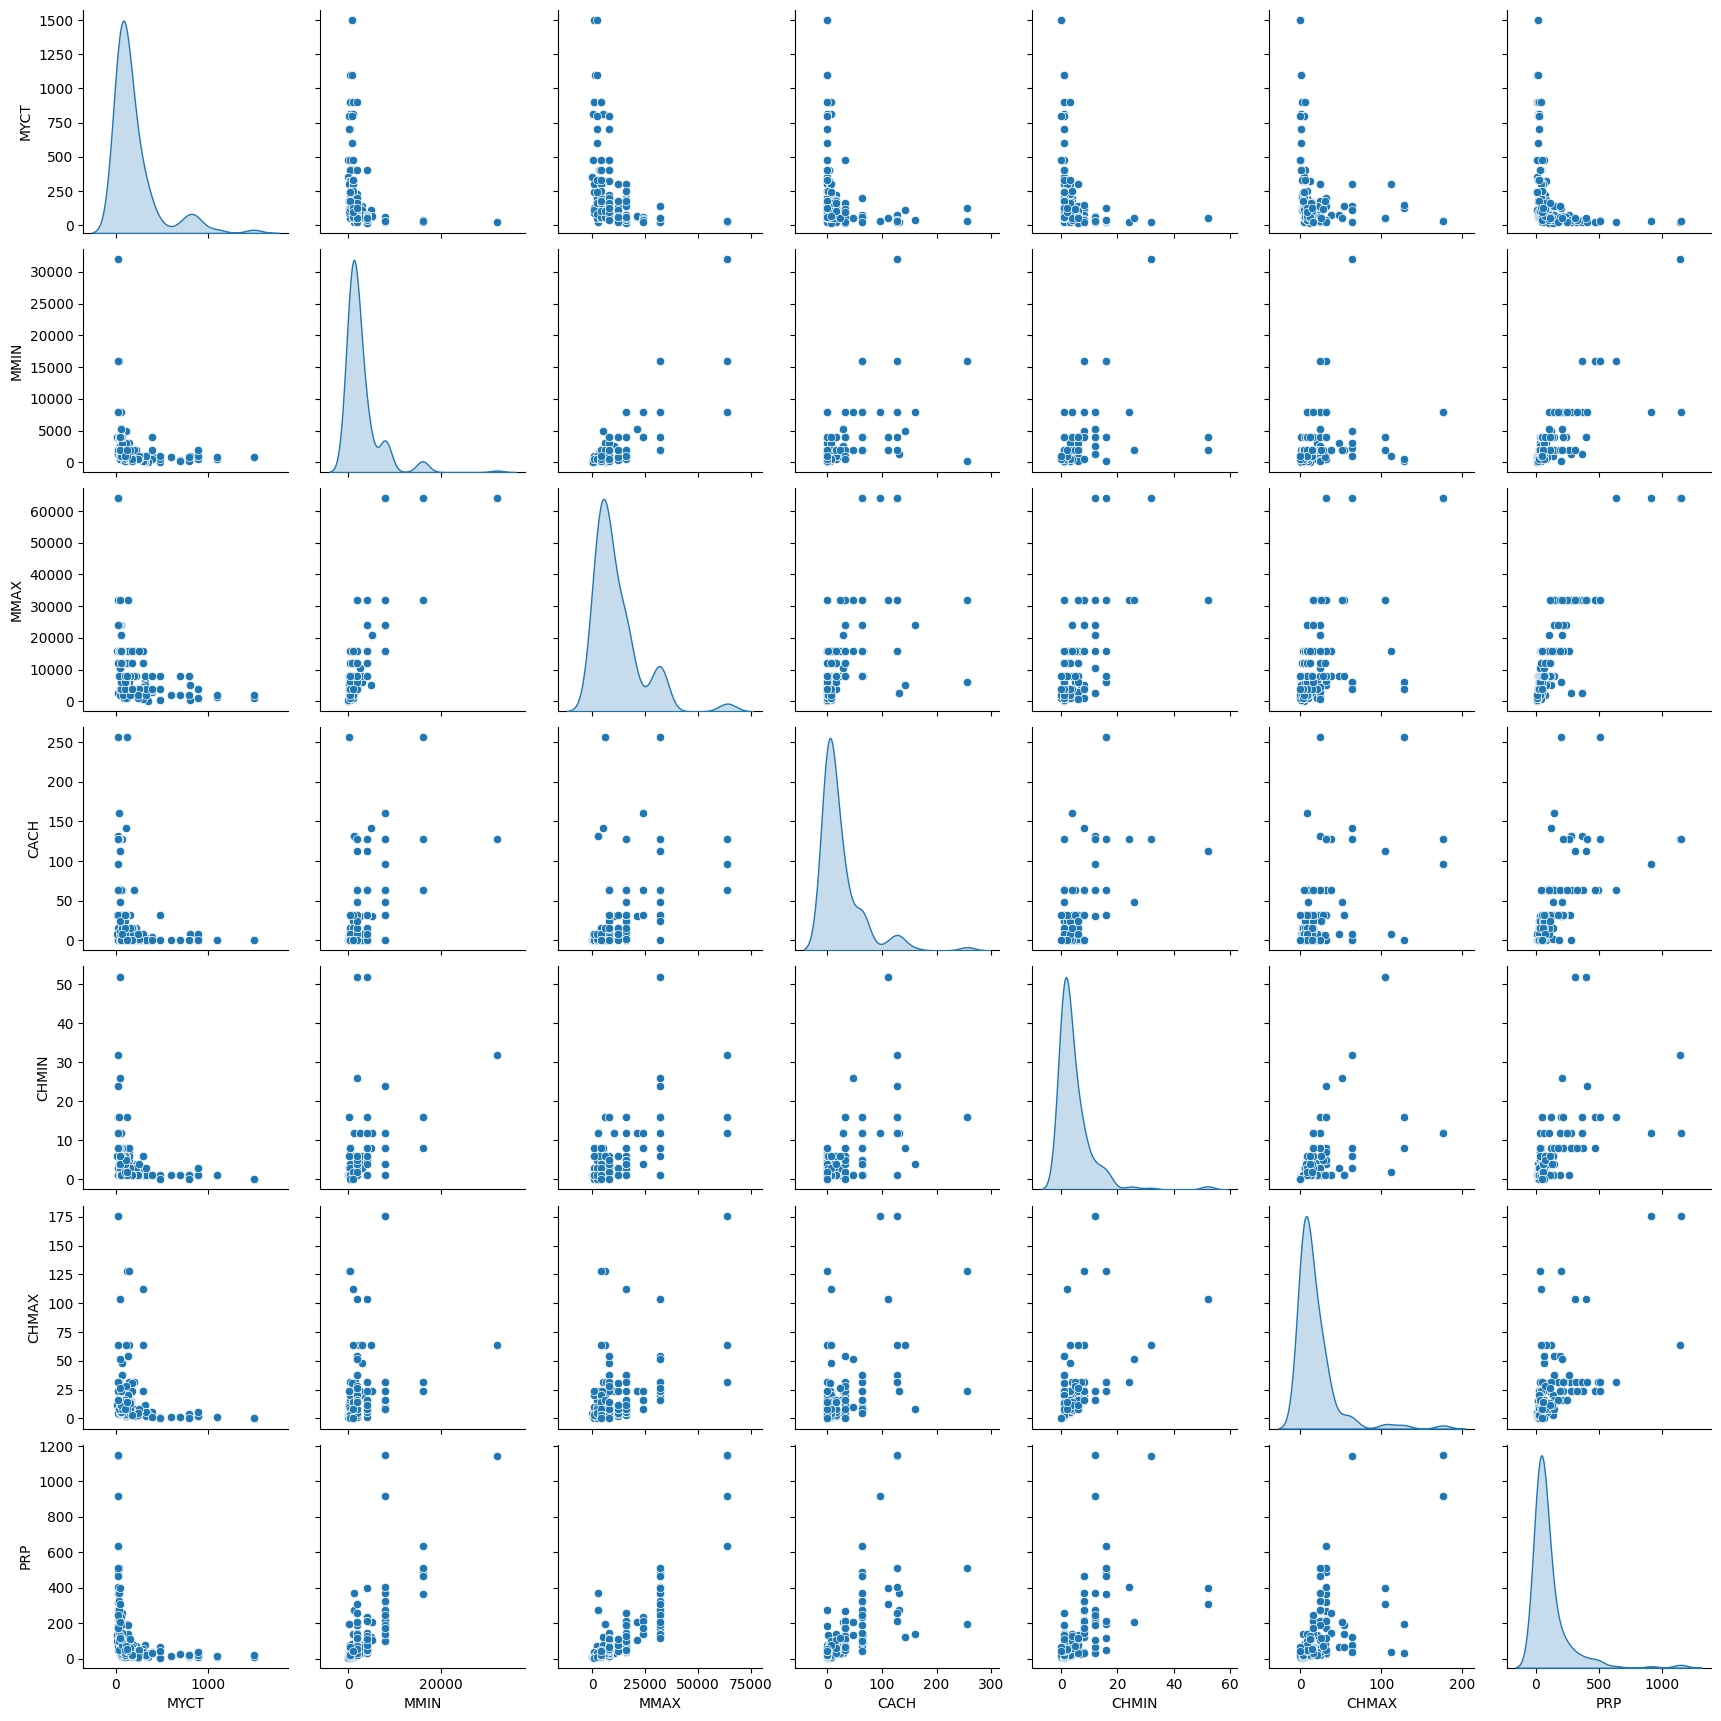

In [ ]:

# Lets visualize the data
sns.pairplot(new_dataset[['MYCT','MMIN','MMAX',
                'CACH', 'CHMIN', 'CHMAX', 'PRP']], diag_kind="kde")

In [ ]:
normalized_dataset = new_dataset.copy()
### --- MIN-MAX NORMALIZATION ---
# To normalize, first we have to get the maximum and minimum value
max_glucose = np.max(normalized_dataset['ERP'])
min_glucose = np.min(normalized_dataset['ERP'])
print('Max Glucose level: {}\t Min Glucose level: {}'.format(max_glucose, min_glucose))

# Remember the .apply() function? We can use that here to normalize EVERY value of the column!
# But first we have to define our normalization function
def normalize_glucose(x):
  return (x-min_glucose)/(max_glucose-min_glucose)

# Now, lets normalize every value of the column!
normalized_dataset['ERP'] = normalized_dataset['ERP'].apply(normalize_glucose)

# And finally, lets check that all the possible UNIQUE values that the column has are indeed between 0 and 1
normalized_dataset['ERP'].unique()

# Indeed, every value has been scaled down between 0 and 1

Max Glucose level: 1238	 Min Glucose level: 15


array([0.15044971, 0.19460343, 0.09566639, 0.22485691, 0.2992641 ,
       0.60016353, 1.        , 0.00654129, 0.00735895, 0.04497138,
       0.08340147, 0.        , 0.04006541, 0.01144726, 0.00572363,
       0.0891251 , 0.01635323, 0.01962388, 0.02044154, 0.02452984,
       0.0106296 , 0.00490597, 0.00981194, 0.07113655, 0.04824203,
       0.10057236, 0.09893704, 0.02371218, 0.01226492, 0.0212592 ,
       0.0318888 , 0.00245298, 0.01717089, 0.01880621, 0.01553557,
       0.00327065, 0.0466067 , 0.03352412, 0.02207686, 0.04905969,
       0.08013083, 0.11610793, 0.00408831, 0.01471791, 0.02616517,
       0.00817661, 0.03025348, 0.02861815, 0.03107114, 0.04742437,
       0.01390025, 0.13082584, 0.03434178, 0.13573181, 0.05478332,
       0.12755519, 0.28291087, 0.2739166 , 0.16762061, 0.00163532,
       0.00899428, 0.01308258, 0.04987735, 0.03597711, 0.04088307,
       0.07031889, 0.08258381, 0.09239575, 0.01798855, 0.02534751,
       0.053148  , 0.05968929, 0.05805397, 0.06541292, 0.07522

In [ ]:

### --- MIN-MAX NORMALIZATION ---
# To normalize, first we have to get the maximum and minimum value
max_glucose = np.max(normalized_dataset['MYCT'])
min_glucose = np.min(normalized_dataset['MYCT'])
print('Max MYCT level: {}\t Min MYCT level: {}'.format(max_glucose, min_glucose))

# Remember the .apply() function? We can use that here to normalize EVERY value of the column!
# But first we have to define our normalization function
def normalize_glucose(x):
  return (x-min_glucose)/(max_glucose-min_glucose)

# Now, lets normalize every value of the column!
normalized_dataset['MYCT'] = normalized_dataset['MYCT'].apply(normalize_glucose)

# And finally, lets check that all the possible UNIQUE values that the column has are indeed between 0 and 1
normalized_dataset['MYCT'].unique()

# Indeed, every value has been scaled down between 0 and 1

Max MYCT level: 1500	 Min MYCT level: 17


array([0.07282535, 0.00809171, 0.00606878, 0.00404585, 0.25826028,
       0.02899528, 0.02225219, 0.22454484, 0.12339852, 0.10114633,
       0.08496291, 0.06271072, 0.20431558, 0.00539447, 0.02629804,
       0.03169252, 0.07821982, 0.5347269 , 0.46055293, 0.08293999,
       0.13688469, 0.52798382, 0.03910991, 0.04922454, 0.05933918,
       0.1065408 , 0.1908294 , 0.10991234, 0.21105866, 0.02697235,
       0.31220499, 0.12542144, 0.06608227, 0.73027647, 0.39312205,
       0.5954147 , 0.14025624, 0.11328388, 0.        , 1.        ,
       0.05596763, 0.08968307, 0.05057316, 0.03708699, 0.0155091 ,
       0.01213756, 0.01416049, 0.02090357, 0.00876601, 0.06405934,
       0.04517869, 0.15711396, 0.09642616, 0.15037087, 0.02360081,
       0.03573837, 0.02832097, 0.06675657, 0.07215105, 0.05461902])

In [ ]:

### --- MIN-MAX NORMALIZATION ---
# To normalize, first we have to get the maximum and minimum value
max_glucose = np.max(normalized_dataset['MMIN'])
min_glucose = np.min(normalized_dataset['MMIN'])
print('Max MMIN level: {}\t Min MMIN level: {}'.format(max_glucose, min_glucose))

# Remember the .apply() function? We can use that here to normalize EVERY value of the column!
# But first we have to define our normalization function
def normalize_glucose(x):
  return (x-min_glucose)/(max_glucose-min_glucose)

# Now, lets normalize every value of the column!
normalized_dataset['MMIN'] = normalized_dataset['MMIN'].apply(normalize_glucose)

# And finally, lets check that all the possible UNIQUE values that the column has are indeed between 0 and 1
normalized_dataset['MMIN'].unique()

# Indeed, every value has been scaled down between 0 and 1

Max MMIN level: 32000	 Min MMIN level: 64


array([0.00601202, 0.24849699, 0.498998  , 1.        , 0.02930862,
       0.01402806, 0.06062124, 0.12324649, 0.        , 0.01440381,
       0.15455912, 0.04496493, 0.09506513, 0.07001503, 0.00200401,
       0.03901553, 0.08003507, 0.16207415, 0.0136523 , 0.01002004,
       0.09193387, 0.02204409, 0.00400802, 0.001002  , 0.0061999 ])

In [ ]:

### --- MIN-MAX NORMALIZATION ---
# To normalize, first we have to get the maximum and minimum value
max_glucose = np.max(normalized_dataset['MMAX'])
min_glucose = np.min(normalized_dataset['MMAX'])
print('Max Glucose level: {}\t Min Glucose level: {}'.format(max_glucose, min_glucose))

# Remember the .apply() function? We can use that here to normalize EVERY value of the column!
# But first we have to define our normalization function
def normalize_glucose(x):
  return (x-min_glucose)/(max_glucose-min_glucose)

# Now, lets normalize every value of the column!
normalized_dataset['MMAX'] = normalized_dataset['MMAX'].apply(normalize_glucose)

# And finally, lets check that all the possible UNIQUE values that the column has are indeed between 0 and 1
normalized_dataset['MMAX'].unique()

# Indeed, every value has been scaled down between 0 and 1

Max Glucose level: 64000	 Min Glucose level: 64


array([0.09284284, 0.4994995 , 0.24924925, 1.        , 0.04592092,
       0.05374124, 0.12412412, 0.        , 0.03028028, 0.0772022 ,
       0.09753504, 0.09597097, 0.03997748, 0.16291291, 0.32698323,
       0.06156156, 0.18668669, 0.00700701, 0.01463964, 0.06938188,
       0.01101101, 0.37437437, 0.02245996])

In [ ]:
### --- MIN-MAX NORMALIZATION ---
# To normalize, first we have to get the maximum and minimum value
max_glucose = np.max(normalized_dataset['PRP'])
min_glucose = np.min(normalized_dataset['PRP'])
print('Max Glucose level: {}\t Min Glucose level: {}'.format(max_glucose, min_glucose))

# Remember the .apply() function? We can use that here to normalize EVERY value of the column!
# But first we have to define our normalization function
def normalize_glucose(x):
  return (x-min_glucose)/(max_glucose-min_glucose)

# Now, lets normalize every value of the column!
normalized_dataset['PRP'] = normalized_dataset['PRP'].apply(normalize_glucose)

# And finally, lets check that all the possible UNIQUE values that the column has are indeed between 0 and 1
normalized_dataset['PRP'].unique()

# Indeed, every value has been scaled down between 0 and 1

Max Glucose level: 1150	 Min Glucose level: 6


array([1.67832168e-01, 2.29895105e-01, 1.87062937e-01, 1.45104895e-01,
       1.10139860e-01, 2.72727273e-01, 3.15559441e-01, 4.22202797e-01,
       5.50699301e-01, 9.94755245e-01, 2.79720280e-02, 2.97202797e-02,
       7.51748252e-02, 1.15384615e-01, 3.49650350e-03, 2.53496503e-02,
       1.13636364e-02, 1.92307692e-02, 2.18531469e-02, 9.96503497e-02,
       2.09790210e-02, 2.36013986e-02, 4.80769231e-02, 6.11888112e-02,
       1.48601399e-02, 5.50699301e-02, 1.83566434e-02, 6.20629371e-02,
       2.34265734e-01, 3.16433566e-01, 2.27272727e-02, 4.98251748e-02,
       8.74125874e-02, 1.76573427e-01, 1.22377622e-02, 2.01048951e-02,
       5.68181818e-02, 1.74825175e-02, 2.62237762e-02, 4.02097902e-02,
       4.72027972e-02, 5.76923077e-02, 1.04895105e-02, 4.89510490e-02,
       1.57342657e-02, 5.24475524e-03, 6.99300699e-03, 8.74125874e-03,
       1.39860140e-02, 1.20629371e-01, 2.21153846e-01, 9.61538462e-03,
       5.06993007e-02, 3.32167832e-02, 3.84615385e-02, 3.40909091e-02,
      

In [ ]:

# Lets check all the columns with the brief Statistical Summary of the dataset
normalized_dataset.describe()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
count,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000
mean,0.125976,0.087800,0.183498,25.205742,4.698565,18.267943,0.087082,0.068954
std,0.175498,0.121454,0.183411,40.628722,6.816274,25.997318,0.140586,0.126539
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.022252,0.022044,0.061562,0.000000,1.000000,5.000000,0.018357,0.010630
50%,0.062711,0.060621,0.124124,8.000000,2.000000,8.000000,0.038462,0.024530
75%,0.140256,0.123246,0.249249,32.000000,6.000000,24.000000,0.093531,0.070319
max,1.000000,1.000000,1.000000,256.000000,52.000000,176.000000,1.000000,1.000000


In [ ]:

# Define the ModelCheckpoint callback
checkpoint_filepath = 'model_checkpoint.h5'  # Path to save the model checkpoints
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,  # Save the entire model
    monitor='val_accuracy',  # Monitor validation accuracy
    mode='max',  # Save the model with the highest validation accuracy
    save_best_only=True) # Save only the best model

# Example model training (replace with your actual model)
# model = tf.keras.models.Sequential([...]) # Your model definition here
# model.compile(...) # Your model compilation here
# history = model.fit(..., callbacks=[model_checkpoint_callback])


In [ ]:

# Splitting dataset into training and testing
train, test = train_test_split(normalized_dataset, test_size=0.2)

# Sepparating both sets into dependent and independent variables
independent_variables = ['MYCT','MMIN','MMAX','CACH', 'CHMIN', 'CHMAX', 'PRP']
dependent_variables = ['ERP']

train_set = train[independent_variables]
train_target = train[dependent_variables]

test_set = test[independent_variables]
test_target = test[dependent_variables]


In [ ]:
# Lets only use EarlyStopping Callback for now
earlystopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5,)

In [ ]:
# Lets build a simple model. NOTE: this is the construction of the architecture of the model!
model = tf.keras.models.Sequential([
  tf.keras.layers.InputLayer(input_shape=(len(independent_variables),)),
  tf.keras.layers.Dense(units=16, activation='relu'),
  tf.keras.layers.Dense(units=16, activation='relu'),
  tf.keras.layers.Dense(units=16, activation='relu'),
  tf.keras.layers.Dense(units=16, activation='relu'),

  # Last layer of the model and its activation function decide if it is a regression or classification problem!
  tf.keras.layers.Dense(units=len(dependent_variables), activation='relu'),
  ])

# Now lets compile the model. NOTE: These are the finishing touches before having a fully functional model
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:

# Now lets train the model!
model.fit(train_set,
          train_target,
          epochs=100,
          batch_size = 32,
          validation_split=0.2,
          callbacks=[earlystopping_callback,model_checkpoint_callback]
        )


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0262 - root_mean_squared_error: 0.1615 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0745
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0248 - root_mean_squared_error: 0.1567 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0745
Epoch 3/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0179 - root_mean_squared_error: 0.1338

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_accuracy available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0230 - root_mean_squared_error: 0.1501 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0745
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0186 - root_mean_squared_error: 0.1316 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0745
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0275 - root_mean_squared_error: 0.1653 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0745
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0343 - root_mean_squared_error: 0.1834 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0745


In [ ]:
# Lets evaluate our model
model.evaluate(x=test_set, y=test_target, batch_size=32)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0107 - root_mean_squared_error: 0.1034


[0.011029277928173542, 0.10502036660909653]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


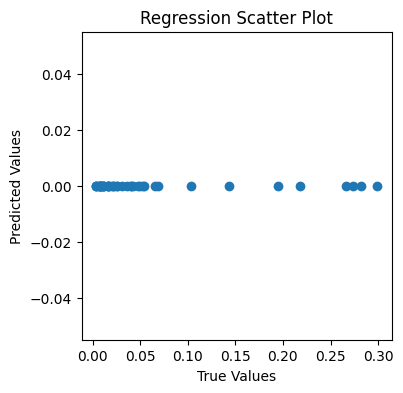

In [ ]:

# Function to plot a scatter plot
def plot_regression_scatter(y_true, y_pred):
    plt.figure(figsize=(4, 4))
    plt.scatter(y_true, y_pred)
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('Regression Scatter Plot')
    plt.show()

# Usage after making predictions:
y_pred = model.predict(test_set)
plot_regression_scatter(test_target, y_pred)

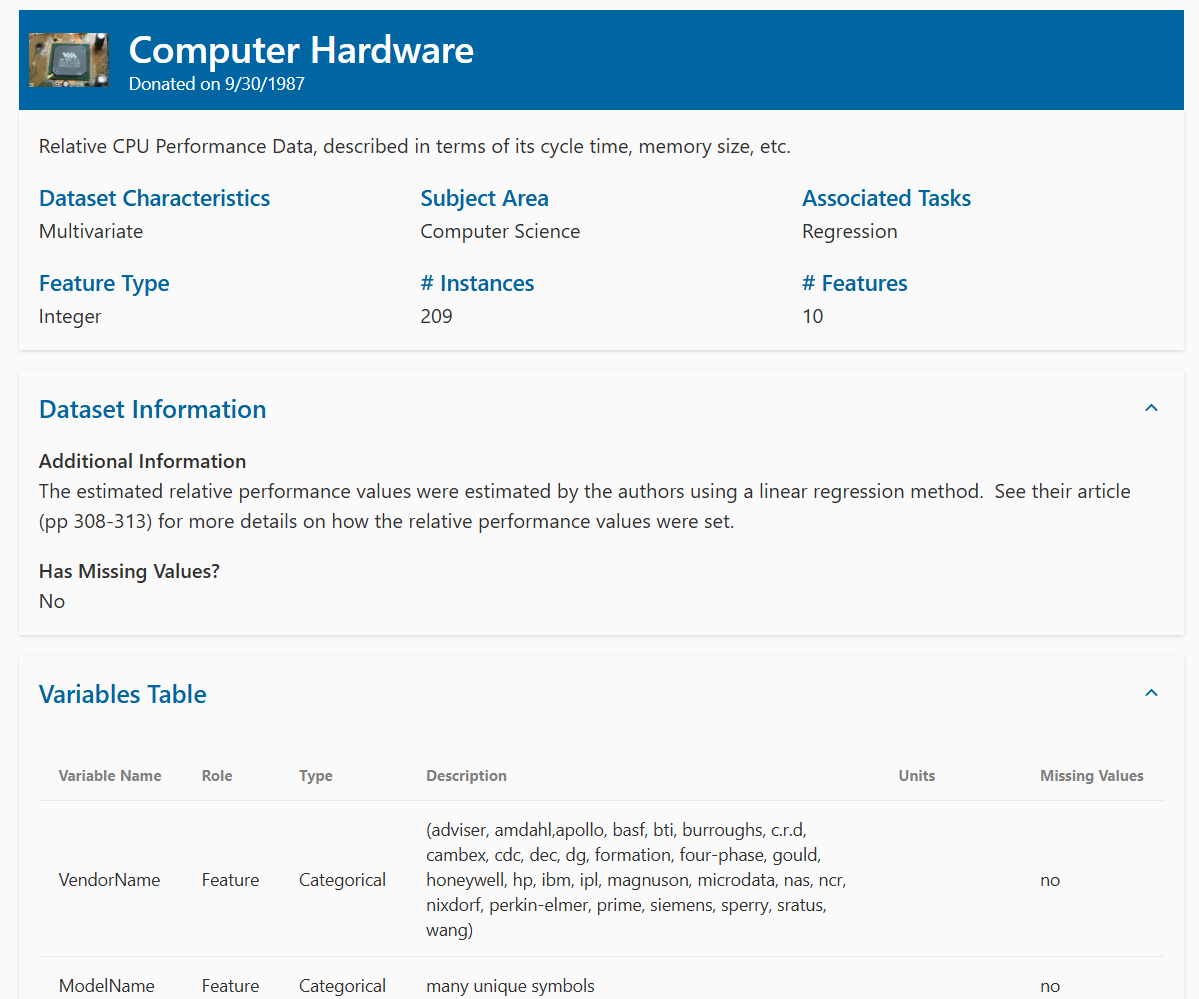

El problema es de regresion, segun lo visto en clase la matriz de confusion se utiliza para problemas de clasificacion unicamente.

Sugerencia 1:

In [ ]:


# 1. Reemplazar la matriz de confusión con una métrica de evaluación más adecuada para la regresión, como el Error Cuadrático Medio (EMM),
# el Error Cuadrático Medio (EMRC), el Error Absoluto Medio (EMA) o el R-cuadrado.
# Estas métricas cuantifican la diferencia entre los valores predichos y los reales.

# 2. Visualizar las predicciones del modelo frente a los valores reales mediante un diagrama de dispersión.
# Esto proporcionará una representación visual
# del rendimiento del modelo y ayudará a identificar áreas donde el modelo tiene un rendimiento inferior.

# READ ME

When you are finished with your laboratory, remember to share it. Make the URL public for Galileo.edu domain or for everyone.
Also, remember to hit Ctrl+S to save your progress.